[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/OpenSpin/SpinStoq/blob/main/examples/quick_start.ipynb)

In [ ]:
import importlib.util, subprocess, sys

# Colab (or any fresh env): install SpinStoq if not already importable.
if importlib.util.find_spec("src.noise") is None:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "git+https://github.com/OpenSpin/SpinStoq.git#egg=openspin-noise[viz]"],
        check=True,
    )

# SpinStoq: Fast Correlated Noise Generator

Generate spin-qubit noise with explicit timestamps and reproducible seeding.

In [1]:
import numpy as np
from src.noise import generate, calibrate, welch
import matplotlib.pyplot as plt

## Example 1: Generate 1/f noise by name

In [2]:
# Generate 100 trajectories, 1e4 Hz sample rate, 2^16 points
res = generate(
    "1/f",
    n_traj=100,
    fs=1e4,               # sample rate [Hz]
    n_points=2**16,
    alpha=1.0,            # 1/f^alpha
    S0=1e-12,             # PSD amplitude [units^2/Hz]
    f0=1.0,               # reference frequency [Hz]
    seed=42,
)

print(f"Trajectories shape: {res.traj.shape}")
print(f"Time grid shape: {res.t.shape}")
print(f"Seed: {res.seed}")
print(f"Spec: {res.spec}")

Trajectories shape: (100, 65536)
Time grid shape: (65536,)
Seed: 42
Spec: {'process': '1/f', 'method': 'timmer_koenig', 'alpha': 1.0, 'S0': 1e-12, 'f0': 1.0, 'f_min': None, 'fs': 10000.0, 'n_points': 65536, 'n_traj': 100, 'dtype': "<class 'numpy.float64'>", 'preset': '1/f'}


## Example 2: Inspect timestamps and first trajectory

In [3]:
# Time grid in seconds
print(f"Time range: {res.t[0]:.6f} to {res.t[-1]:.6f} seconds")
print(f"Time step: {res.t[1] - res.t[0]:.9f} seconds")
print(f"Sample rate: {res.fs} Hz")

# First trajectory
traj_0 = res.traj[0, :]
print(f"\nTrajectory[0] stats: mean={traj_0.mean():.3e}, std={traj_0.std():.3e}")

Time range: 0.000000 to 6.553500 seconds
Time step: 0.000100000 seconds
Sample rate: 10000.0 Hz

Trajectory[0] stats: mean=-6.617e-23, std=3.177e-06


## Example 3: Plot trajectory and power spectrum

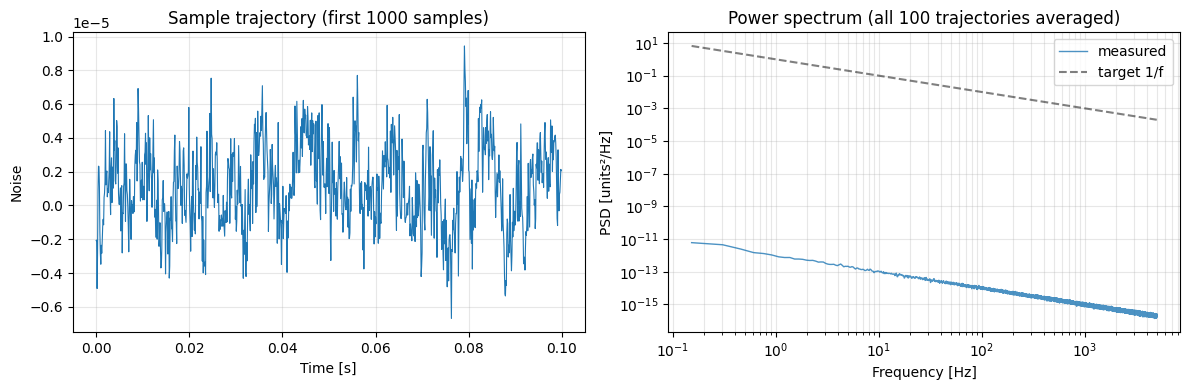

In [4]:
# Compute PSD via Welch
f, S = welch(res.traj, fs=res.fs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Time domain: first 1000 samples
ax1.plot(res.t[:1000], res.traj[0, :1000], linewidth=0.8)
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Noise')
ax1.set_title('Sample trajectory (first 1000 samples)')
ax1.grid(alpha=0.3)

# Frequency domain
ax2.loglog(f[1:], S[1:], label='measured', linewidth=1, alpha=0.8)
ax2.loglog(f[1:], 1.0/f[1:], 'k--', alpha=0.5, label='target 1/f')
ax2.set_xlabel('Frequency [Hz]')
ax2.set_ylabel('PSD [units²/Hz]')
ax2.set_title('Power spectrum (all 100 trajectories averaged)')
ax2.legend()
ax2.grid(alpha=0.3, which='both')

fig.tight_layout()
plt.show()

## Example 4: Generate OU-sum (physically-motivated 1/f)

In [5]:
# OU-sum: sum of Lorentzians (better for physics simulations)
res_ou = generate(
    "ou_sum",
    n_traj=50,
    fs=1e4,
    n_points=2**14,
    alpha=1.0,
    S0=1e-12,
    f0=1.0,
    n_components_per_decade=8,
    seed=42,
    backend="numpy",  # or "numba" for speed
)

print(f"OU-sum trajectories: {res_ou.traj.shape}")
print(f"Process spec: {res_ou.spec['process']}")

OU-sum trajectories: (50, 16384)
Process spec: ou_sum


## Example 5: From measured trace (model-free surrogate)

In [6]:
# Create a synthetic measured trace
trace_measured = np.random.randn(1, 2**14)  # 1 channel, 16384 samples

# Calibrate: estimate statistics and create surrogate generator
gen = calibrate(trace_measured, fs=1e4, method="circulant")

# Generate 200 surrogate trajectories matching the measured PSD
res_surrogate = gen.sample(n_traj=200, n_points=2**14, seed=42)

print(f"Surrogate trajectories: {res_surrogate.traj.shape}")
print(f"Timestamps included: {res_surrogate.t.shape}")

Surrogate trajectories: (200, 16384)
Timestamps included: (16384,)


## Example 6: List available named processes

In [7]:
from src.noise import list_processes

processes = list_processes()
print("Available noise processes:")
for name in processes:
    print(f"  - {name}")

Available noise processes:
  - 1/f
  - charge_noise_SiGe
  - charge_noise_SiMOS
  - ou
  - ou_sum
  - ou_sum_default
  - rtn
  - rtn_dominated
  - spatial_fluctuators


## Example 7: Spatial correlations (distributed-fluctuator ensemble)

In [ ]:
from src.noise.generators.spatial import generate_spatial_separable

# 5 sites, non-uniform 1D spacing; target spatial covariance decays with distance
site_positions = np.array([0.0, 1.0, 2.0, 4.0, 8.0])
xi_corr = 2.0  # correlation length
D = np.abs(site_positions[:, None] - site_positions[None, :])
K = np.exp(-D / xi_corr)

res_spatial = generate_spatial_separable(
    K, n_traj=200, fs=1e3, n_points=2**12,
    temporal="1/f", alpha=1.0, S0=1e-12, f0=1.0, seed=7,
)
print(f"Trajectories shape: {res_spatial.traj.shape}")  # (n_traj, M_sites, n_time)

# Recover the empirical zero-lag spatial correlation matrix
X = res_spatial.traj - res_spatial.traj.mean(axis=-1, keepdims=True)
cov = np.einsum('tik,tjk->ij', X, X, optimize=True) / (X.shape[0] * X.shape[-1])
std = np.sqrt(np.diag(cov))
corr_measured = cov / np.outer(std, std)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4))

im1 = ax1.imshow(K, vmin=-1, vmax=1, cmap='RdBu_r')
ax1.set_title('Target correlation K')
fig.colorbar(im1, ax=ax1, fraction=0.046)

im2 = ax2.imshow(corr_measured, vmin=-1, vmax=1, cmap='RdBu_r')
ax2.set_title('Measured correlation')
fig.colorbar(im2, ax=ax2, fraction=0.046)

# Correlation vs pairwise distance: target curve + recovered points
M = len(site_positions)
dist, cval = [], []
for i in range(M):
    for j in range(i + 1, M):
        dist.append(abs(site_positions[i] - site_positions[j]))
        cval.append(corr_measured[i, j])
d_grid = np.linspace(0, D.max(), 100)
ax3.plot(d_grid, np.exp(-d_grid / xi_corr), 'k--', alpha=0.6, label='target')
ax3.scatter(dist, cval, label='measured')
ax3.set_xlabel('Site separation')
ax3.set_ylabel('Correlation')
ax3.set_title('Spatial correlation vs distance')
ax3.legend()
ax3.grid(alpha=0.3)

fig.tight_layout()
plt.show()

## Example 8: Save and load results

In [8]:
import tempfile
import os

# Save to .npz file (includes metadata)
with tempfile.TemporaryDirectory() as tmpdir:
    path = os.path.join(tmpdir, "noise_result.npz")
    res.save(path)
    print(f"Saved to {path}")
    
    # Load it back
    from src.noise import NoiseResult
    res_loaded = NoiseResult.load(path)
    
    print(f"Loaded shape: {res_loaded.traj.shape}")
    print(f"Metadata preserved: seed={res_loaded.seed}, fs={res_loaded.fs}")

Saved to /var/folders/wj/x78z9z710q7csr068fhd10bxk7mx3x/T/tmpa0otnryb/noise_result.npz
Loaded shape: (100, 65536)
Metadata preserved: seed=42, fs=10000.0
